In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import tqdm
from pybedtools import BedTool

In [3]:
df_hap1_hifi = pd.read_csv(f'/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/hifi_reads_to_hs1.minimap2.haplotagged_ground_truth.hap1.bed.gz',
                      sep='\t', names=['chrom', 'start', 'end', 'score', 'hap',
                                       'coverage', 'mod_count', 'unmod_count','ratio'], 
                      engine='pyarrow', skiprows=7)
df_hap2_hifi = pd.read_csv(f'/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/hifi_reads_to_hs1.minimap2.haplotagged_ground_truth.hap2.bed.gz',
                      sep='\t', names=['chrom', 'start', 'end', 'score', 'hap',
                                       'coverage', 'mod_count', 'unmod_count','ratio'], 
                      engine='pyarrow', skiprows=7)

df_hap1_ont = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp1.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

df_hap2_ont = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp2.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

df_hap1_ul_ont = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ul_ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp1.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])
df_hap2_ul_ont = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ul_ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp2.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

In [2]:
df_hap1_hifi_icr = pd.read_csv(f'/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/hifi_reads_to_hs1.minimap2.haplotagged_ground_truth.hap1.icr.bed',
                      sep='\t', names=['chrom', 'start', 'end', 'score', 'hap',
                                       'coverage', 'mod_count', 'unmod_count','ratio'], 
                      engine='pyarrow', skiprows=7)
df_hap2_hifi_icr = pd.read_csv(f'/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/hifi_reads_to_hs1.minimap2.haplotagged_ground_truth.hap2.icr.bed',
                      sep='\t', names=['chrom', 'start', 'end', 'score', 'hap',
                                       'coverage', 'mod_count', 'unmod_count','ratio'], 
                      engine='pyarrow', skiprows=7)

df_hap1_ont_icr = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp1.icr.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

df_hap2_ont_icr = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp2.icr.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

df_hap1_ul_ont_icr = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ul_ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp1.icr.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])
df_hap2_ul_ont_icr = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ul_ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp2.icr.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

In [5]:
df_hap1_hifi_icr = df_hap1_hifi_icr[df_hap1_hifi_icr.coverage >= 10]
df_hap2_hifi_icr = df_hap2_hifi_icr[df_hap2_hifi_icr.coverage >= 10]

df_hap1_ont_icr = df_hap1_ont_icr[df_hap1_ont_icr.coverage >= 10]
df_hap2_ont_icr = df_hap2_ont_icr[df_hap2_ont_icr.coverage >= 10]

df_hap1_ul_ont_icr = df_hap1_ul_ont_icr[df_hap1_ul_ont_icr.coverage >= 10]
df_hap2_ul_ont_icr = df_hap2_ul_ont_icr[df_hap2_ul_ont_icr.coverage >= 10]

In [6]:
df_hap1_hifi = df_hap1_hifi[df_hap1_hifi.coverage >= 10]
df_hap2_hifi = df_hap2_hifi[df_hap2_hifi.coverage >= 10]

df_hap1_ont = df_hap1_ont[df_hap1_ont.coverage >= 10]
df_hap2_ont = df_hap2_ont[df_hap2_ont.coverage >= 10]

df_hap1_ul_ont = df_hap1_ul_ont[df_hap1_ul_ont.coverage >= 10]
df_hap2_ul_ont = df_hap2_ul_ont[df_hap2_ul_ont.coverage >= 10]

In [7]:
df_hifi = df_hap1_hifi.set_index(['chrom', 'start', 'end']).join(df_hap2_hifi.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_hifi.dropna(inplace=True)

df_ont = df_hap1_ont.set_index(['chrom', 'start', 'end']).join(df_hap2_ont.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_ont.dropna(inplace=True)

df_ul_ont = df_hap1_ul_ont.set_index(['chrom', 'start', 'end']).join(df_hap2_ul_ont.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_ul_ont.dropna(inplace=True)



In [8]:
df_hifi_icr = df_hap1_hifi_icr.set_index(['chrom', 'start', 'end']).join(df_hap2_hifi_icr.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_hifi_icr.dropna(inplace=True)

df_ont_icr = df_hap1_ont_icr.set_index(['chrom', 'start', 'end']).join(df_hap2_ont_icr.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_ont_icr.dropna(inplace=True)

df_ul_ont_icr = df_hap1_ul_ont_icr.set_index(['chrom', 'start', 'end']).join(df_hap2_ul_ont_icr.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_ul_ont_icr.dropna(inplace=True)

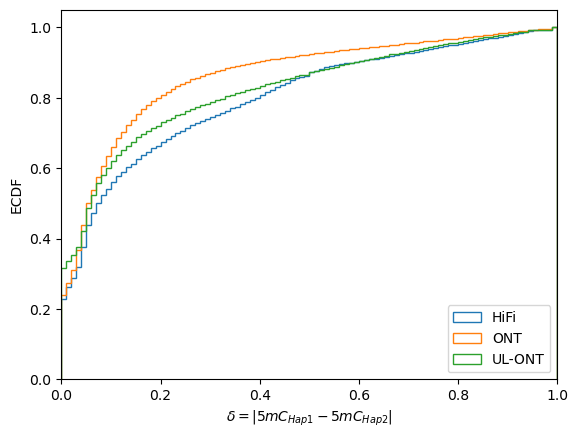

In [7]:
fig, ax = plt.subplots()
ax.hist(np.abs(df_hifi.ratio_1 - df_hifi.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_hifi.shape[0], df_hifi.shape[0]), histtype='step', label='HiFi')
ax.hist(np.abs(df_ont.ratio_1 - df_ont.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ont.shape[0], df_ont.shape[0]), histtype='step', label='ONT')
ax.hist(np.abs(df_ul_ont.ratio_1 - df_ul_ont.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ul_ont.shape[0], df_ul_ont.shape[0]), histtype='step', label='UL-ONT')
ax.set_xlim([0, 1])
ax.set_ylabel('ECDF')
ax.set_xlabel(r'$\delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
ax.legend(loc='lower right')

In [8]:
base_dir = '/scratch/gpfs/AKEY/apfennig/LongHap/HG002/deepvariant/'
diff_meth_hifi = pd.concat([pd.read_csv(base_dir + f"deepvariant_hifi_hs1.minimap2.hifi.chr{chrom}.filtered_snps_indels.longhap_meth_diff_meth_sites.tab",
                                   sep='\t', engine='pyarrow') for chrom in np.arange(1, 23)])
diff_meth_hifi = diff_meth_hifi.groupby(['chrom', 'start', 'end', 'hap']).last().reset_index()

diff_meth_hifi = diff_meth_hifi.loc[diff_meth_hifi.hap == 'hap1', 
                          ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']).join(
    diff_meth_hifi.loc[diff_meth_hifi.hap == 'hap2', 
                  ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']), 
    lsuffix='_hap1', rsuffix='_hap2')

diff_meth_hifi.dropna(inplace=True)


diff_meth_ont = pd.concat([pd.read_csv(base_dir + f"deepvariant_hifi_hs1.minimap2.ont_r10.4.1_dorado.chr{chrom}.filtered_snps_indels.longhap_meth_diff_meth_sites.tab",
                                   sep='\t', engine='pyarrow') for chrom in np.arange(1, 23)])
diff_meth_ont = diff_meth_ont.groupby(['chrom', 'start', 'end', 'hap']).last().reset_index()

diff_meth_ont = diff_meth_ont.loc[diff_meth_ont.hap == 'hap1', 
                          ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']).join(
    diff_meth_ont.loc[diff_meth_ont.hap == 'hap2', 
                  ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']), 
    lsuffix='_hap1', rsuffix='_hap2')

diff_meth_ont.dropna(inplace=True)


diff_meth_ul_ont = pd.concat([pd.read_csv(base_dir + f"deepvariant_hifi_hs1.minimap2.ul_ont_r10.4.1_dorado.chr{chrom}.filtered_snps_indels.longhap_meth_diff_meth_sites.tab",
                                   sep='\t', engine='pyarrow') for chrom in np.arange(1, 23)])
diff_meth_ul_ont = diff_meth_ul_ont.groupby(['chrom', 'start', 'end', 'hap']).last().reset_index()

diff_meth_ul_ont = diff_meth_ul_ont.loc[diff_meth_ul_ont.hap == 'hap1', 
                          ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']).join(
    diff_meth_ul_ont.loc[diff_meth_ul_ont.hap == 'hap2', 
                  ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']), 
    lsuffix='_hap1', rsuffix='_hap2')

diff_meth_ul_ont.dropna(inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/gpfs/AKEY/apfennig/LongHap/HG002/deepvariant/deepvariant_hifi_hs1.minimap2.ont_r10.4.1_dorado.chr1.filtered_snps_indels.longhap_meth_diff_meth_sites.tab'

In [ ]:
df_hifi_longhap = df_hifi.join(diff_meth_hifi).dropna()
df_ont_longhap = df_ont.join(diff_meth_ont).dropna()
df_ul_ont_longhap = df_ul_ont.join(diff_meth_ul_ont).dropna()

Text(0, 0.5, 'ECDF')

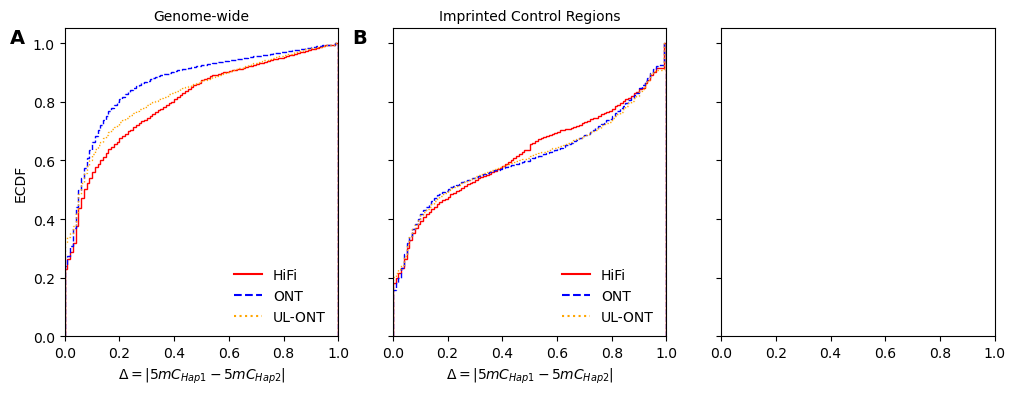

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)

handles = [Line2D([0], [0], color='red', ls='-', label='HiFi'),
           Line2D([0], [0], color='blue', ls='--', label='ONT'),
           Line2D([0], [0], color='orange', ls=':', label='UL-ONT')]

ax[0].hist(np.abs(df_hifi.ratio_1 - df_hifi.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_hifi.shape[0], df_hifi.shape[0]), histtype='step', label='HiFi',
          color='red', ls='-')
ax[0].hist(np.abs(df_ont.ratio_1 - df_ont.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ont.shape[0], df_ont.shape[0]), histtype='step', label='ONT',
          color='blue', ls='--')
ax[0].hist(np.abs(df_ul_ont.ratio_1 - df_ul_ont.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ul_ont.shape[0], df_ul_ont.shape[0]), histtype='step', label='UL-ONT',
          color='orange', ls=':')
ax[0].set_xlim([0, 1])
ax[0].set_xlabel(r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
ax[0].legend(handles=handles, frameon=False, loc='lower right')
ax[0].set_title('Genome-wide', fontsize=10)
ax[0].annotate("A", (-0.2, 1), xycoords=ax[0].transAxes, fontsize=14, fontweight='bold', ha='left', va='top')

ax[1].hist(np.abs(df_hifi_icr.ratio_1 - df_hifi_icr.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_hifi_icr.shape[0], df_hifi_icr.shape[0]), histtype='step', label='HiFi',
          color='red', ls='-')
ax[1].hist(np.abs(df_ont_icr.ratio_1 - df_ont_icr.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ont_icr.shape[0], df_ont_icr.shape[0]), histtype='step', label='ONT',
          color='blue', ls='--')
ax[1].hist(np.abs(df_ul_ont_icr.ratio_1 - df_ul_ont_icr.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ul_ont_icr.shape[0], df_ul_ont_icr.shape[0]), histtype='step', label='UL-ONT',
          color='orange', ls=':')
ax[1].set_xlim([0, 1])
ax[1].set_xlabel(r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
ax[1].legend(handles=handles, frameon=False, loc='lower right')
ax[1].set_title('Imprinted Control Regions', fontsize=10)
ax[1].annotate("B", (-0.15, 1), xycoords=ax[1].transAxes, fontsize=14, fontweight='bold', ha='left', va='top')


# ax[2].hist(np.abs(df_hifi_longhap.ratio_1 - df_hifi_longhap.ratio_2) / 100, bins=100, cumulative=True, 
#         weights=np.repeat(1/df_hifi_longhap.shape[0], df_hifi_longhap.shape[0]), histtype='step', label='HiFi',
#           color='red', ls='-')
# ax[2].hist(np.abs(df_ont_longhap.ratio_1 - df_ont_longhap.ratio_2) / 100, bins=100, cumulative=True, 
#         weights=np.repeat(1/df_ont_longhap.shape[0], df_ont_longhap.shape[0]), histtype='step', label='ONT',
#           color='blue', ls='--')
# ax[2].hist(np.abs(df_ul_ont_longhap.ratio_1 - df_ul_ont_longhap.ratio_2) / 100, bins=100, cumulative=True, 
#         weights=np.repeat(1/df_ul_ont_longhap.shape[0], df_ul_ont_longhap.shape[0]), histtype='step', 
#         label='UL-ONT', color='orange', ls=':')
# ax[2].set_xlim([0, 1])
# ax[2].set_xlabel(r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
# ax[2].legend(handles=handles, frameon=False, loc='lower right')
# ax[2].set_title('LongHap ascertained DMS', fontsize=10)
# ax[2].annotate("C", (-0.15, 1), xycoords=ax[1].transAxes, fontsize=14, fontweight='bold', ha='left', va='top')
ax[0].set_ylabel('ECDF')


In [ ]:
fig, ax = plt.subplots()

sns.regplot(x=np.abs(df_hifi_longhap.ratio_1 - df_hifi_longhap.ratio_2) / 100, 
            y=np.abs(df_hifi_longhap.ratio_hap1 - df_hifi_longhap.ratio_hap2) / 100, ax=ax,
            scatter=False, line_kws={"ls": '-'}, color='red')

sns.regplot(x=np.abs(df_ont_longhap.ratio_1 - df_ont_longhap.ratio_2) / 100, 
            y=np.abs(df_ont_longhap.ratio_hap1 - df_ont_longhap.ratio_hap2) / 100, ax=ax,
            scatter=False, line_kws={"ls": '--'}, color='blue')

sns.regplot(x=np.abs(df_ul_ont_longhap.ratio_1 - df_ul_ont_longhap.ratio_2) / 100, 
            y=np.abs(df_ul_ont_longhap.ratio_hap1 - df_ul_ont_longhap.ratio_hap2) / 100, ax=ax,
            scatter=False, line_kws={"ls": ':'}, color='orange')

ax.legend(handles=handles, frameon=False, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal')
ax.set_xlabel('True ' + r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
ax.set_ylabel('LongHap inferred ' + r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')


In [17]:
np.sum(np.abs(df_hifi_icr.ratio_1 - df_hifi_icr.ratio_2) > 40) / np.abs(df_hifi_icr.ratio_1 - df_hifi_icr.ratio_2).shape[0]

np.float64(0.4228943826592052)

In [14]:
np.abs(df_ul_ont_icr.ratio_1 - df_ul_ont_icr.ratio_2).shape[0]

15839

In [113]:
diff_meth_ul_ont.shape

(30728, 2)

In [ ]:
aa